In [76]:
import pandas as pd
import seaborn as sns

In [77]:
df=pd.read_csv('EcommerceCustomers.CSV')

In [78]:
df

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872\nLake Jamiefurt,...",Tan,33.237660,13.566160,36.417985,3.746573,573.847438
496,katrina56@gmail.com,"172 Owen Divide Suite 497\nWest Richard, CA 19320",PaleVioletRed,34.702529,11.695736,37.190268,3.576526,529.049004
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633\nSouth Chadburgh, ...",Cornsilk,32.646777,11.499409,38.332576,4.958264,551.620146
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808\nBrendachester, TX...",Teal,33.322501,12.391423,36.840086,2.336485,456.469510


In [79]:
df=df.drop(columns=['Email','Address','Avatar'])

In [80]:
df

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620146
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [81]:
df.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


## Relation between the features and target columns
- Avg. Session Length & Yearly Amount Spent -> 0.35 |weak relation|
- Time on App & Yearly Amount Spent -> 0.49 |moderate relation|
- Time on Website & Yearly Amount Spent -> -0 |No relation|
- Length of Membership	& Yearly Amount Spent -> 0.80 |Strong relation|

- So we can ignore the Time on Website feature as it has no realtion at all.

In [82]:
df=df.drop(columns=['Time on Website'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Length of Membership  500 non-null    float64
 3   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

<Axes: >

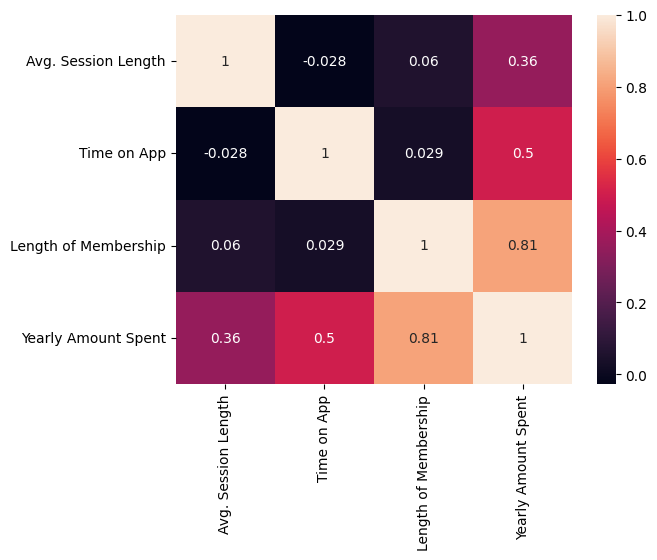

In [84]:
cor=df.corr(numeric_only=True)
sns.heatmap(cor,annot=True)

In [85]:
x=df[['Avg. Session Length','Time on App','Length of Membership']]
y=df['Yearly Amount Spent']

In [86]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [87]:
model=LinearRegression()

In [88]:
model.fit(Xtrain,Ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [89]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
Ypred_train=model.predict(Xtrain)
score=r2_score(Ytrain,Ypred_train)
score

0.9854090539258055

- The R² score is above 80%, indicating that the model explains a large portion of the variance in customer spending and performs well on the training data.

In [90]:
m=mean_absolute_error(Ytrain,Ypred_train)
m

7.729588234089813

In [91]:
r=root_mean_squared_error(Ytrain,Ypred_train)
r

9.793936900949646

- Since RMSE is close to MAE, the prediction errors are relatively consistent and there is no strong indication of extreme outliers affecting model performance.

- Now we will check for the unseen data

In [92]:
Ypred_test=model.predict(Xtest)

In [93]:
score=r2_score(Ytest,Ypred_test)
score

0.9777203388443935

In [94]:
m=mean_absolute_error(Ytest,Ypred_test)
m

8.583564847951864

In [95]:
r=root_mean_squared_error(Ytest,Ypred_test)
r

10.503470181008497

- The RMSE and MAE values on the test set are close, suggesting stable prediction performance. The model generalizes well to unseen customer data.

### The model is a good fit because the training R² score is 98.54% and the testing R² score is 97.77%. The difference between them is only 0.77%, which shows that the model has captured the patterns properly and generalizes well to unseen data.